In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import cleaning_stephanie as cs
import seaborn as sns

In [62]:
Name_Soil_Temp = "Champion_AGDM.csv"
Name_Soil_Mois= "Champion AGDM.csv"

#Manning AGDM

## Soil Temp

In [63]:
df_Soil_Temp_AGDM=pd.read_csv(Name_Soil_Temp)
df_Soil_Temp_AGDM.head()

,time,soil_temp_deg_C_at_5_cm_depth,soil_temp_deg_C_at_20_cm_depth,soil_temp_deg_C_at_50_cm_depth,soil_temp_deg_C_at_100_cm_depth
0,2005-05-01 00:00:00,7.0,8.4,9.0,9.1
1,2005-05-01 01:00:00,6.6,8.3,9.0,9.0
2,2005-05-01 02:00:00,6.3,8.2,9.0,9.0
3,2005-05-01 03:00:00,5.9,8.2,9.1,9.0
4,2005-05-01 04:00:00,5.7,8.1,9.1,9.1


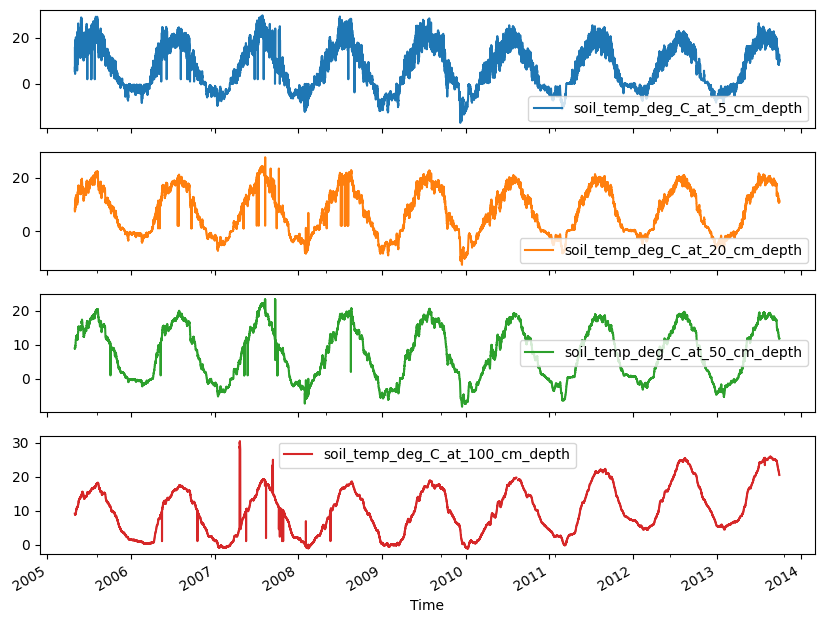

In [64]:
df_Soil_Temp_AGDM["time"] = pd.to_datetime(df_Soil_Temp_AGDM["time"])
df_Soil_Temp_AGDM = df_Soil_Temp_AGDM.set_index("time")

variables = df_Soil_Temp_AGDM.columns.values

df_Soil_Temp_AGDM[variables].plot(subplots=True, figsize=(10, 8), sharex=True)

plt.xlabel("Time")
plt.show()

In [65]:
df_Soil_Temp_AGDM.mean()

,0
soil_temp_deg_C_at_5_cm_depth,7.097864
soil_temp_deg_C_at_20_cm_depth,7.311775
soil_temp_deg_C_at_50_cm_depth,7.468588
soil_temp_deg_C_at_100_cm_depth,10.199394


In [66]:
df_Soil_Temp_AGDM.max()

,0
soil_temp_deg_C_at_5_cm_depth,29.7
soil_temp_deg_C_at_20_cm_depth,27.6
soil_temp_deg_C_at_50_cm_depth,23.4
soil_temp_deg_C_at_100_cm_depth,30.5


In [67]:
df_Soil_Temp_AGDM.min()

,0
soil_temp_deg_C_at_5_cm_depth,-16.9
soil_temp_deg_C_at_20_cm_depth,-12.6
soil_temp_deg_C_at_50_cm_depth,-8.2
soil_temp_deg_C_at_100_cm_depth,-1.2


In [68]:
NaN_Original=df_Soil_Temp_AGDM.isna().sum()
NaN_Original

,0
soil_temp_deg_C_at_5_cm_depth,106516
soil_temp_deg_C_at_20_cm_depth,106518
soil_temp_deg_C_at_50_cm_depth,106517
soil_temp_deg_C_at_100_cm_depth,106517


In [69]:
df_Soil_Temp_AGDM.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,73211
soil_temp_deg_C_at_20_cm_depth,73209
soil_temp_deg_C_at_50_cm_depth,73210
soil_temp_deg_C_at_100_cm_depth,73210


# Specific TH Stuck
In this method we remove any set of repeated values larger than  `sens_stuck `. This method is better for the model fitting part.

##Neighborhood Outliers

This proposal eliminates an entire neighborhood of size `segment_th` surrounding any value considered an outlier. This is because, when using the returns approach, the first point might be an outlier with respect to the previous normal trend, but subsequent points will be normal with respect to the outlier. However, only the first detected outlier will be eliminated, as subsequent returns would be normal with respect to the removed outlier.

The current method looks for outliers with a positive or negative jump and searches the surroundings for an opposite jump that adjusts to the normal value without counting intermediate NaN values ​​that might be present to remove the section completely.

###Returns Removed Using Percentils
An outlier is considered to be any return that is above the `up` percentile or below the `low` percentile.


In [70]:
from cleaning_stephanie import soil_temp_percentil_neighborhood_outliers

Text(0.5, 0, 'Time')

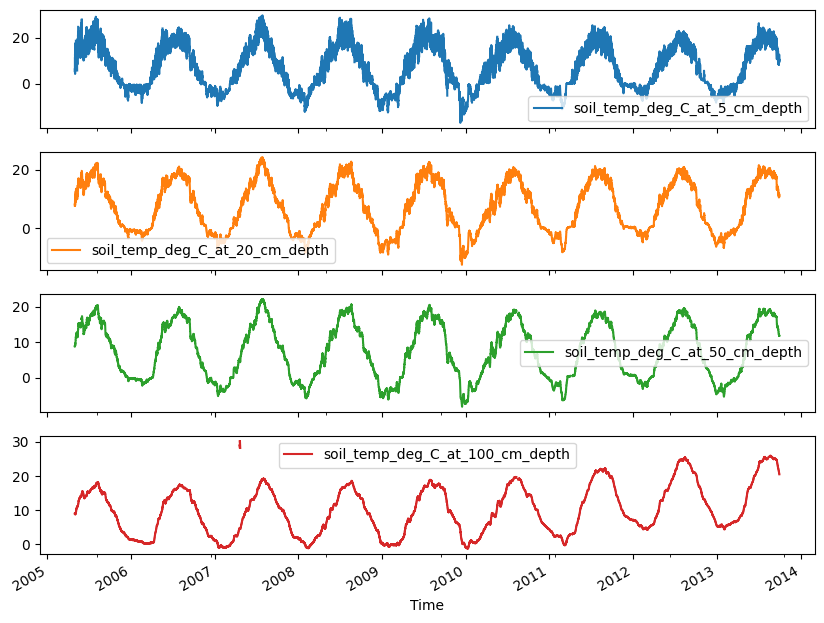

In [71]:
df_Clean_per,returns_per_clean=soil_temp_percentil_neighborhood_outliers(df=df_Soil_Temp_AGDM,low=0.00001,up=0.99999,th_returns=200,sens_stuck=50,segment_th = 2)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")

In [72]:
df_Clean_per.to_csv("Champion_AGDM_temperature_cleaned.csv")

In [73]:
df_Clean_per.max()

,0
soil_temp_deg_C_at_5_cm_depth,29.7
soil_temp_deg_C_at_20_cm_depth,24.3
soil_temp_deg_C_at_50_cm_depth,22.2
soil_temp_deg_C_at_100_cm_depth,30.2


In [74]:
df_Clean_per.min()

,0
soil_temp_deg_C_at_5_cm_depth,-16.9
soil_temp_deg_C_at_20_cm_depth,-12.6
soil_temp_deg_C_at_50_cm_depth,-8.2
soil_temp_deg_C_at_100_cm_depth,-1.2


In [75]:
df_Clean_per.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,70129
soil_temp_deg_C_at_20_cm_depth,70918
soil_temp_deg_C_at_50_cm_depth,71522
soil_temp_deg_C_at_100_cm_depth,70546


In [76]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_temp_deg_C_at_5_cm_depth,109598
soil_temp_deg_C_at_20_cm_depth,108809
soil_temp_deg_C_at_50_cm_depth,108205
soil_temp_deg_C_at_100_cm_depth,109181


In [77]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_temp_deg_C_at_5_cm_depth,3082
soil_temp_deg_C_at_20_cm_depth,2291
soil_temp_deg_C_at_50_cm_depth,1688
soil_temp_deg_C_at_100_cm_depth,2664


In [78]:
df_Clean_per

,soil_temp_deg_C_at_5_cm_depth,soil_temp_deg_C_at_20_cm_depth,soil_temp_deg_C_at_50_cm_depth,soil_temp_deg_C_at_100_cm_depth
time,,,,
2005-05-01 00:00:00,NaN,NaN,NaN,NaN
2005-05-01 01:00:00,NaN,NaN,NaN,NaN
2005-05-01 02:00:00,6.3,8.2,9.0,9.0
2005-05-01 03:00:00,5.9,8.2,9.1,9.0
2005-05-01 04:00:00,5.7,8.1,9.1,9.1
...,...,...,...,...
2025-10-31 19:00:00,NaN,NaN,NaN,NaN
2025-10-31 20:00:00,NaN,NaN,NaN,NaN
2025-10-31 21:00:00,NaN,NaN,NaN,NaN


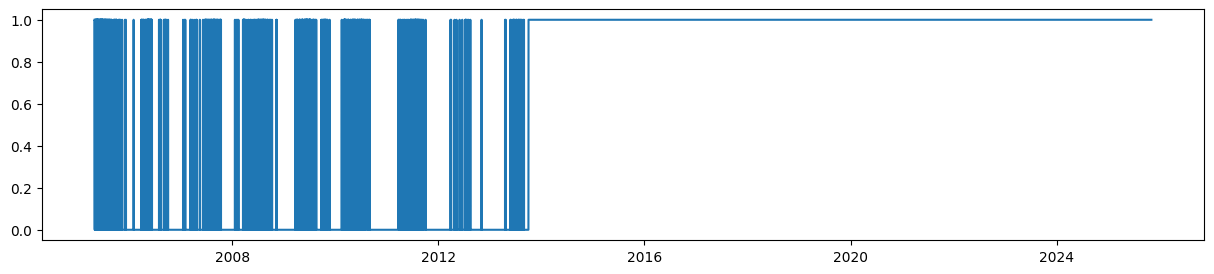

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,3))
plt.plot(df_Clean_per['soil_temp_deg_C_at_5_cm_depth'].isna())
plt.show()

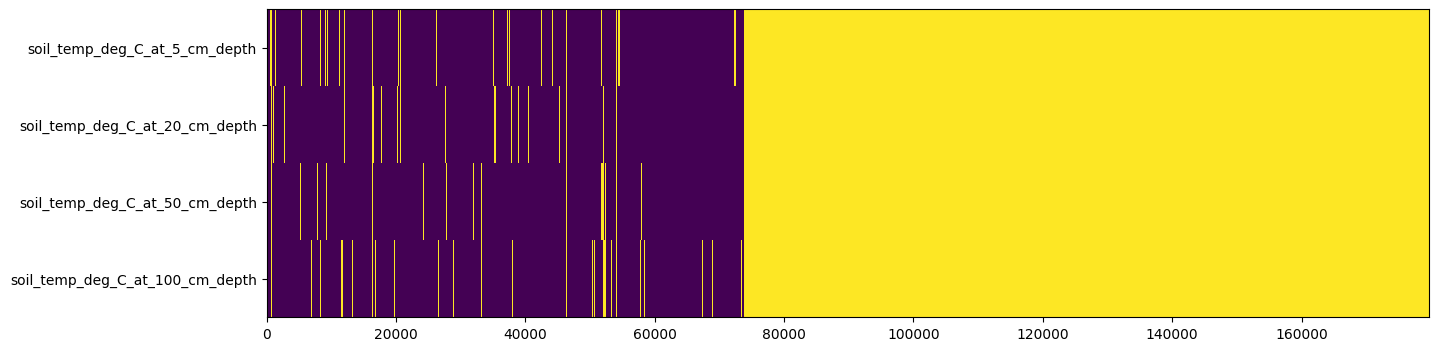

In [80]:
plt.figure(figsize=(15,4))
plt.imshow(
    df_Clean_per.isna().T,
    aspect='auto',
    interpolation='nearest'
)
plt.yticks(range(len(df_Clean_per.columns)), df_Clean_per.columns)
plt.show()

In [81]:
df_Clean_per.shape


(179727, 4)

In [82]:
df_Clean_per.isna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,109598
soil_temp_deg_C_at_20_cm_depth,108809
soil_temp_deg_C_at_50_cm_depth,108205
soil_temp_deg_C_at_100_cm_depth,109181


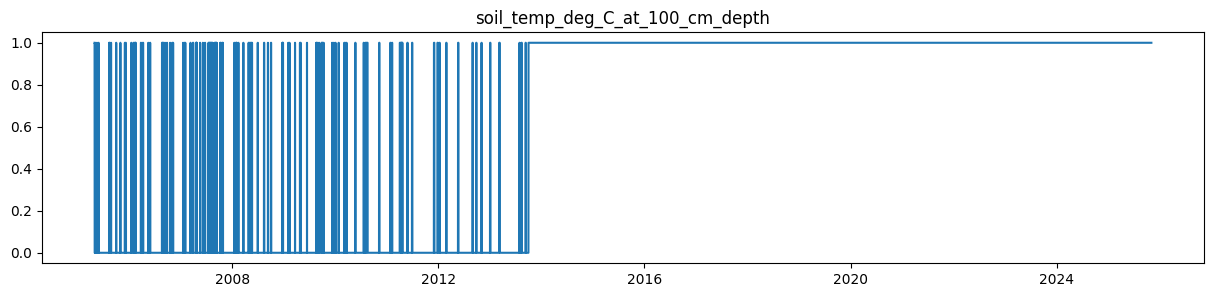

In [83]:
col = 'soil_temp_deg_C_at_100_cm_depth'

plt.figure(figsize=(15,3))
plt.plot(df_Clean_per[col].isna().astype(int))
plt.title(col)
plt.show()

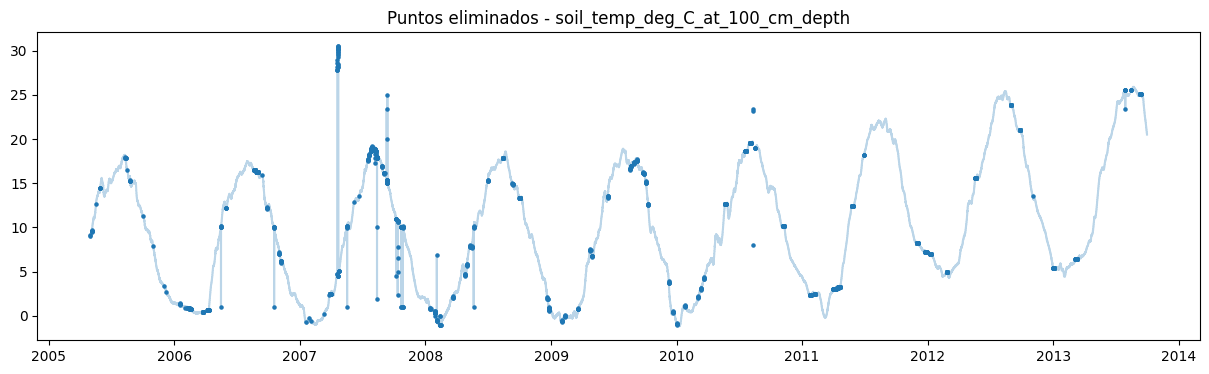

In [84]:
col = 'soil_temp_deg_C_at_100_cm_depth'

# puntos que fueron eliminados en el limpio
bad_mask = df_Clean_per[col].isna()

plt.figure(figsize=(15,4))

# serie original completa
plt.plot(df_Soil_Temp_AGDM.index,
         df_Soil_Temp_AGDM[col],
         alpha=0.3)

# puntos eliminados resaltados
plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
            df_Soil_Temp_AGDM.loc[bad_mask, col],
            s=5)

plt.title(f'Puntos eliminados - {col}')
plt.show()

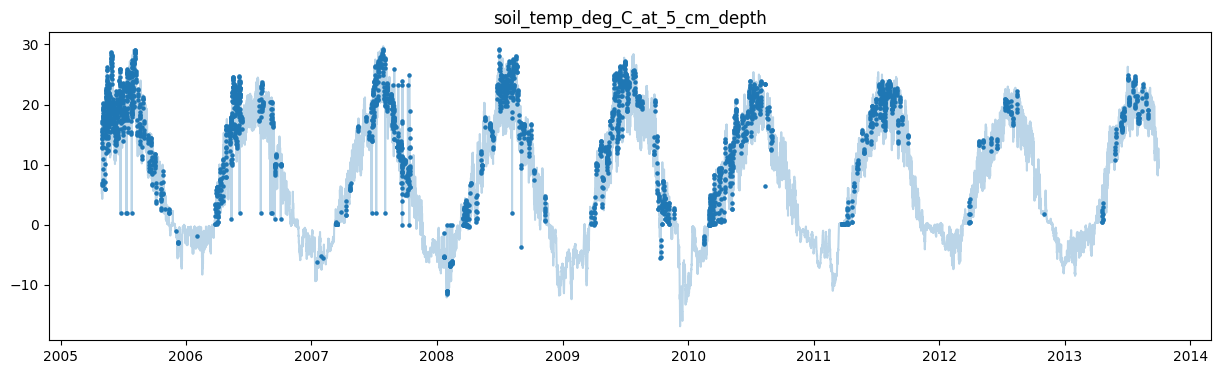

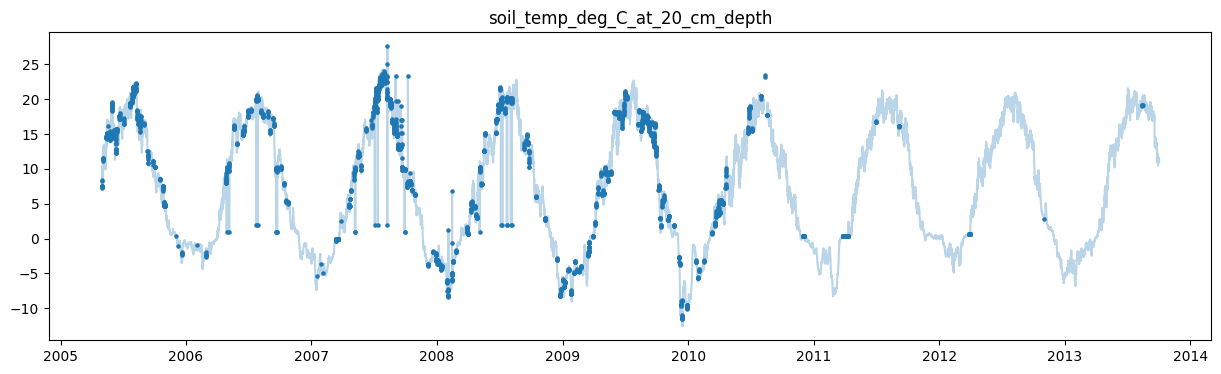

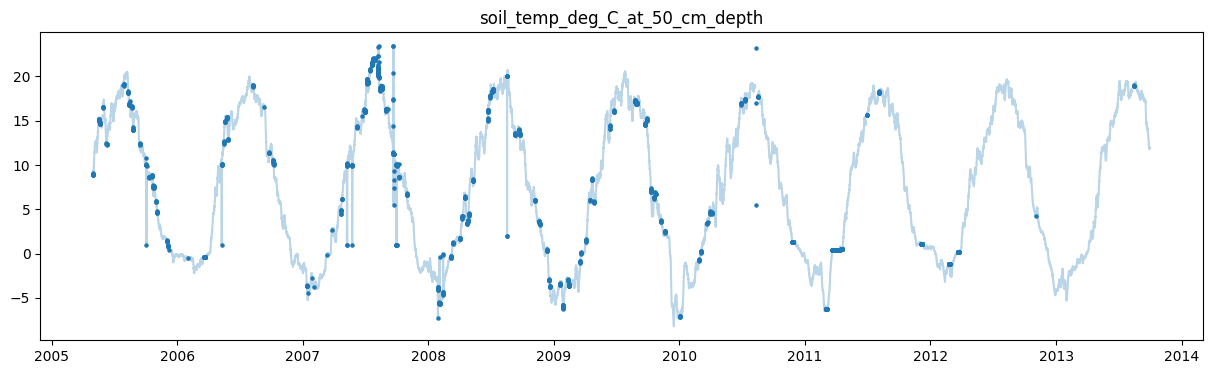

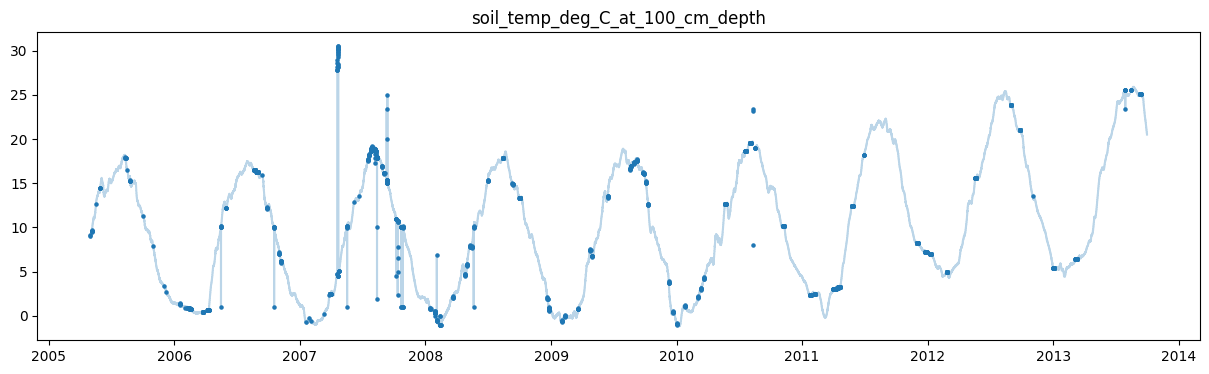

In [85]:
for col in df_Soil_Temp_AGDM.columns:

    bad_mask = (
    df_Clean_per[col].isna()
    & df_Soil_Temp_AGDM[col].notna()
    )

    plt.figure(figsize=(15,4))

    plt.plot(df_Soil_Temp_AGDM.index,
             df_Soil_Temp_AGDM[col],
             alpha=0.3)

    plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
                df_Soil_Temp_AGDM.loc[bad_mask, col],
                s=5)

    plt.title(col)
    plt.show()

In [86]:
df_Clean_per.isna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,109598
soil_temp_deg_C_at_20_cm_depth,108809
soil_temp_deg_C_at_50_cm_depth,108205
soil_temp_deg_C_at_100_cm_depth,109181


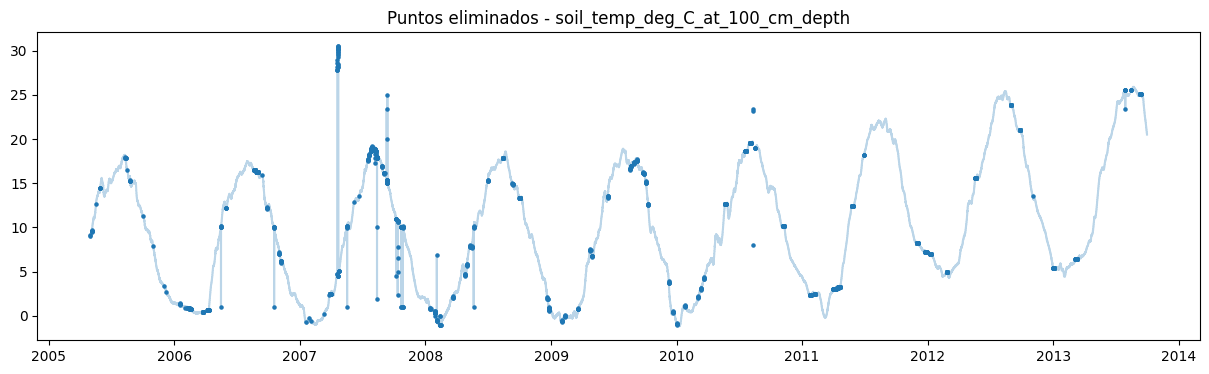

In [87]:
col = 'soil_temp_deg_C_at_100_cm_depth'

# puntos que fueron eliminados en el limpio
bad_mask = df_Clean_per[col].isna()

plt.figure(figsize=(15,4))

# serie original completa
plt.plot(df_Soil_Temp_AGDM.index,
         df_Soil_Temp_AGDM[col],
         alpha=0.3)

# puntos eliminados resaltados
plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
            df_Soil_Temp_AGDM.loc[bad_mask, col],
            s=5)

plt.title(f'Puntos eliminados - {col}')
plt.show()

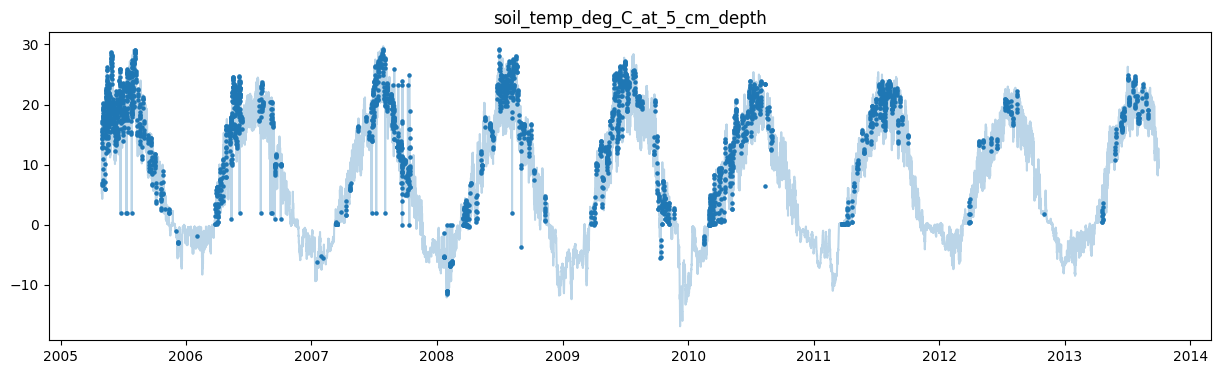

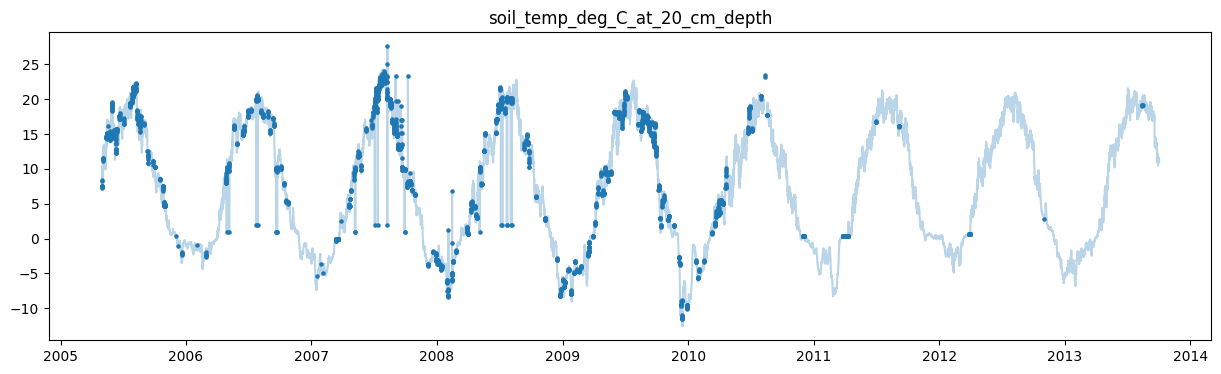

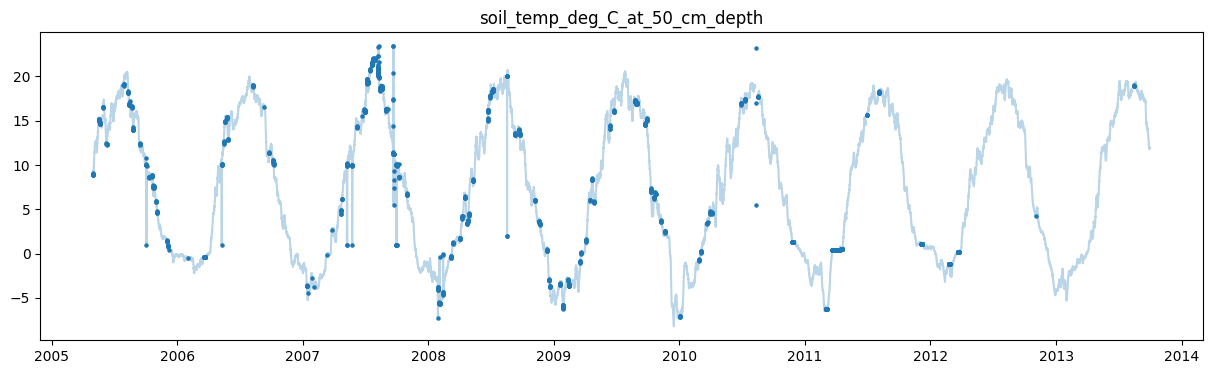

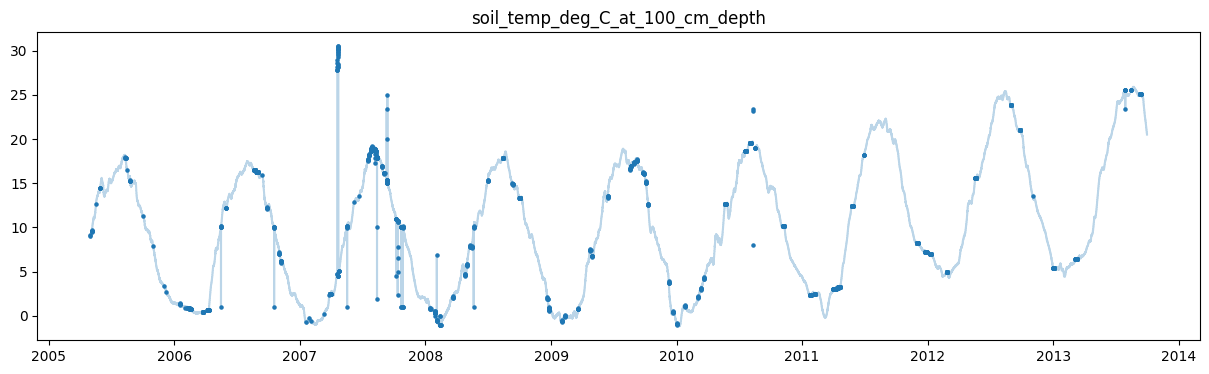

In [88]:
for col in df_Soil_Temp_AGDM.columns:

    bad_mask = (
    df_Clean_per[col].isna()
    & df_Soil_Temp_AGDM[col].notna()
    )

    plt.figure(figsize=(15,4))

    plt.plot(df_Soil_Temp_AGDM.index,
             df_Soil_Temp_AGDM[col],
             alpha=0.3)

    plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
                df_Soil_Temp_AGDM.loc[bad_mask, col],
                s=5)

    plt.title(col)
    plt.show()

# Z Scores Not Used


In [89]:
from cleaning_stephanie import soil_temp_zscores_neighborhood_outliers

Text(0.5, 0, 'Time')

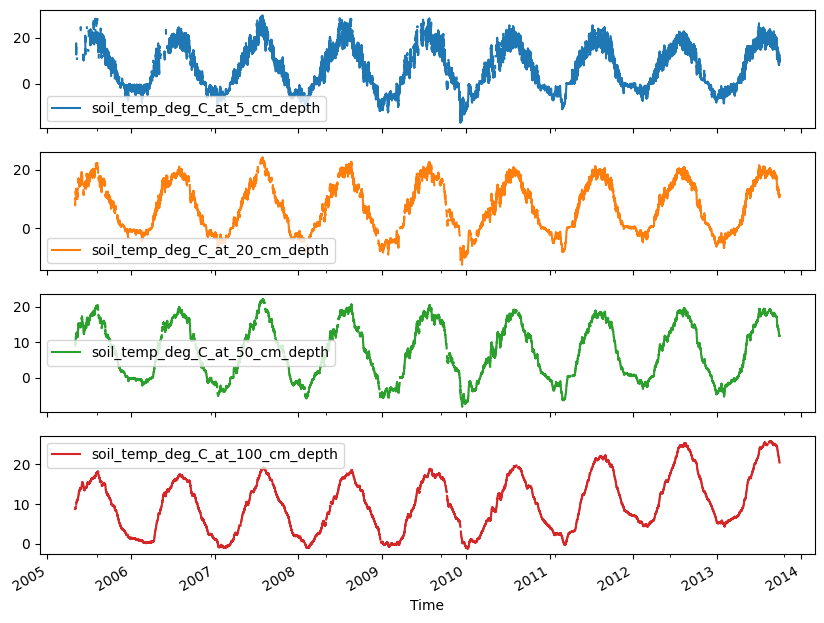

In [90]:
df_Clean_per,returns_per_clean=soil_temp_zscores_neighborhood_outliers(df=df_Soil_Temp_AGDM,zscr_sd=3,th_returns=2,sens_stuck=20,segment_th = 20)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [91]:
df_Clean_per.max()

,0
soil_temp_deg_C_at_5_cm_depth,29.7
soil_temp_deg_C_at_20_cm_depth,24.3
soil_temp_deg_C_at_50_cm_depth,22.2
soil_temp_deg_C_at_100_cm_depth,25.9


In [92]:
df_Clean_per.min()

,0
soil_temp_deg_C_at_5_cm_depth,-16.9
soil_temp_deg_C_at_20_cm_depth,-12.6
soil_temp_deg_C_at_50_cm_depth,-8.2
soil_temp_deg_C_at_100_cm_depth,-1.2


In [93]:
df_Clean_per.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,55126
soil_temp_deg_C_at_20_cm_depth,60073
soil_temp_deg_C_at_50_cm_depth,63824
soil_temp_deg_C_at_100_cm_depth,57029


In [94]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_temp_deg_C_at_5_cm_depth,124601
soil_temp_deg_C_at_20_cm_depth,119654
soil_temp_deg_C_at_50_cm_depth,115903
soil_temp_deg_C_at_100_cm_depth,122698


In [95]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_temp_deg_C_at_5_cm_depth,18085
soil_temp_deg_C_at_20_cm_depth,13136
soil_temp_deg_C_at_50_cm_depth,9386
soil_temp_deg_C_at_100_cm_depth,16181


# Moisture

In [96]:
df_Soil_Temp_AGDM=pd.read_csv(Name_Soil_Mois)
df_Soil_Temp_AGDM.head()

,time,soil_moisture_percent_at_5_cm_depth,soil_moisture_percent_at_20_cm_depth,soil_moisture_percent_at_50_cm_depth,soil_moisture_percent_at_100_cm_depth
0,2005-05-01 00:00:00,12.5,24.6,10.3,9.1
1,2005-05-01 01:00:00,12.5,24.6,10.3,9.1
2,2005-05-01 02:00:00,12.5,24.6,10.3,9.1
3,2005-05-01 03:00:00,12.4,24.6,10.3,9.1
4,2005-05-01 04:00:00,12.4,24.6,10.3,9.1


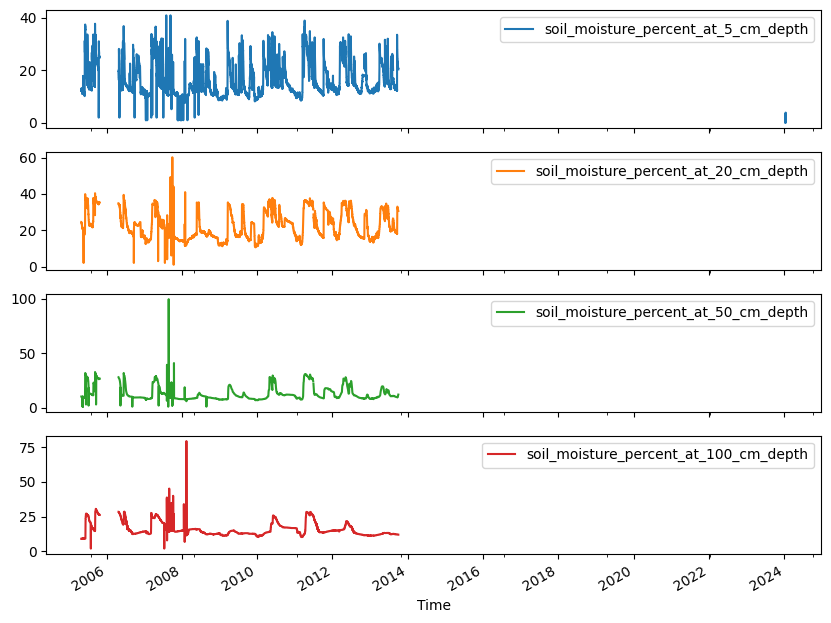

In [97]:
df_Soil_Temp_AGDM["time"] = pd.to_datetime(df_Soil_Temp_AGDM["time"])
df_Soil_Temp_AGDM = df_Soil_Temp_AGDM.set_index("time")

variables = df_Soil_Temp_AGDM.columns.values

df_Soil_Temp_AGDM[variables].plot(subplots=True, figsize=(10, 8), sharex=True)

plt.xlabel("Time")
plt.show()

In [98]:
df_Soil_Temp_AGDM.mean()

,0
soil_moisture_percent_at_5_cm_depth,16.332957
soil_moisture_percent_at_20_cm_depth,22.499441
soil_moisture_percent_at_50_cm_depth,12.938508
soil_moisture_percent_at_100_cm_depth,15.649626


In [99]:
df_Soil_Temp_AGDM.max()

,0
soil_moisture_percent_at_5_cm_depth,41.0
soil_moisture_percent_at_20_cm_depth,60.2
soil_moisture_percent_at_50_cm_depth,99.6
soil_moisture_percent_at_100_cm_depth,79.4


In [100]:
df_Soil_Temp_AGDM.min()

,0
soil_moisture_percent_at_5_cm_depth,0.0
soil_moisture_percent_at_20_cm_depth,1.0
soil_moisture_percent_at_50_cm_depth,1.0
soil_moisture_percent_at_100_cm_depth,2.0


In [101]:
NaN_Original=df_Soil_Temp_AGDM.isna().sum()
NaN_Original

,0
soil_moisture_percent_at_5_cm_depth,110831
soil_moisture_percent_at_20_cm_depth,110890
soil_moisture_percent_at_50_cm_depth,110890
soil_moisture_percent_at_100_cm_depth,110975


In [102]:
df_Soil_Temp_AGDM.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,68896
soil_moisture_percent_at_20_cm_depth,68837
soil_moisture_percent_at_50_cm_depth,68837
soil_moisture_percent_at_100_cm_depth,68752


###Returns Removed Using Percentils
An outlier is considered to be any return that is above the `up` percentile or below the `low` percentile.

Text(0.5, 0, 'Time')

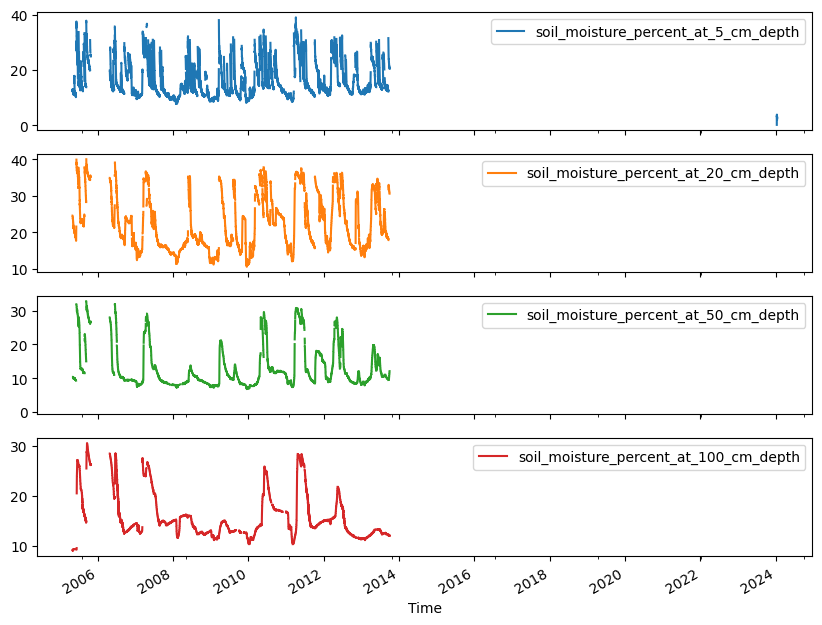

In [103]:
df_Clean_per,returns_per_clean=soil_temp_percentil_neighborhood_outliers(df=df_Soil_Temp_AGDM,low=0.00001,up=0.99999,th_returns=200,sens_stuck=50,segment_th = 2)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [104]:
df_Clean_per.max()

,0
soil_moisture_percent_at_5_cm_depth,39.0
soil_moisture_percent_at_20_cm_depth,40.0
soil_moisture_percent_at_50_cm_depth,32.8
soil_moisture_percent_at_100_cm_depth,30.6


In [105]:
df_Clean_per.min()

,0
soil_moisture_percent_at_5_cm_depth,0.2
soil_moisture_percent_at_20_cm_depth,10.6
soil_moisture_percent_at_50_cm_depth,1.0
soil_moisture_percent_at_100_cm_depth,9.0


In [106]:
df_Clean_per.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,66682
soil_moisture_percent_at_20_cm_depth,64020
soil_moisture_percent_at_50_cm_depth,40860
soil_moisture_percent_at_100_cm_depth,30532


In [107]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_moisture_percent_at_5_cm_depth,113045
soil_moisture_percent_at_20_cm_depth,115707
soil_moisture_percent_at_50_cm_depth,138867
soil_moisture_percent_at_100_cm_depth,149195


In [108]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_moisture_percent_at_5_cm_depth,2214
soil_moisture_percent_at_20_cm_depth,4817
soil_moisture_percent_at_50_cm_depth,27977
soil_moisture_percent_at_100_cm_depth,38220


# Z Scores Not Used


In [109]:
from cleaning_stephanie import soil_temp_zscores_neighborhood_outliers

Text(0.5, 0, 'Time')

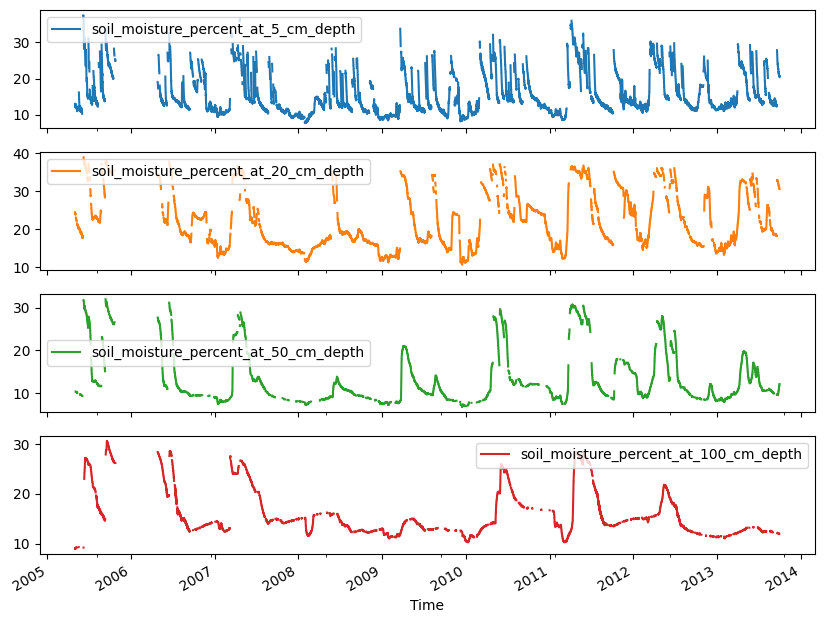

In [110]:
df_Clean_per,returns_per_clean=soil_temp_zscores_neighborhood_outliers(df=df_Soil_Temp_AGDM,zscr_sd=3,th_returns=2,sens_stuck=20,segment_th = 20)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [111]:
df_Clean_per.max()

,0
soil_moisture_percent_at_5_cm_depth,37.5
soil_moisture_percent_at_20_cm_depth,39.0
soil_moisture_percent_at_50_cm_depth,32.0
soil_moisture_percent_at_100_cm_depth,30.6


In [112]:
df_Clean_per.min()

,0
soil_moisture_percent_at_5_cm_depth,7.8
soil_moisture_percent_at_20_cm_depth,10.6
soil_moisture_percent_at_50_cm_depth,6.8
soil_moisture_percent_at_100_cm_depth,9.0


In [113]:
df_Clean_per.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,57600
soil_moisture_percent_at_20_cm_depth,45794
soil_moisture_percent_at_50_cm_depth,21760
soil_moisture_percent_at_100_cm_depth,18972


In [114]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_moisture_percent_at_5_cm_depth,122127
soil_moisture_percent_at_20_cm_depth,133933
soil_moisture_percent_at_50_cm_depth,157967
soil_moisture_percent_at_100_cm_depth,160755


In [115]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_moisture_percent_at_5_cm_depth,11296
soil_moisture_percent_at_20_cm_depth,23043
soil_moisture_percent_at_50_cm_depth,47077
soil_moisture_percent_at_100_cm_depth,49780
